# Coffee shop revenue 

# Problem statment  
### Coffee shop businesses generate large amounts of data related to sales, customers, and operations. However, understanding how these factors impact overall revenue can be challenging. This project aims to analyze key variables influencing revenue and identify important patterns. Using data analysis and machine learning techniques, the goal is to predict coffee shop revenue accurately. The insights can help in making better business decisions and improving profitability.


## importing librarys 

In [29]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder , LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             classification_report, f1_score, auc)


## importing file path 

In [30]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\coffee_shop_revenue.csv")
df

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42
...,...,...,...,...,...,...,...
1995,372,6.41,11,4,466.11,913,2816.85
1996,105,3.01,11,7,12.62,235,337.97
1997,89,5.28,16,9,376.64,310,951.34
1998,403,9.41,7,12,452.49,577,4266.21


## Data Preprosesing 

In [31]:
# Returns the number of rows and columns in the dataset.
df.shape

(2000, 7)

In [32]:
# is used to display the names (labels) of all columns present in a DataFrame.
df.columns

Index(['Number_of_Customers_Per_Day', 'Average_Order_Value',
       'Operating_Hours_Per_Day', 'Number_of_Employees',
       'Marketing_Spend_Per_Day', 'Location_Foot_Traffic', 'Daily_Revenue'],
      dtype='object')

In [33]:
# Shows the first 5 rows of the dataset.
df.head()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42


In [34]:
# Shows the last 5 rows of the dataset.
df.tail()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
1995,372,6.41,11,4,466.11,913,2816.85
1996,105,3.01,11,7,12.62,235,337.97
1997,89,5.28,16,9,376.64,310,951.34
1998,403,9.41,7,12,452.49,577,4266.21
1999,89,6.88,13,14,78.46,322,914.24


In [35]:
# counts the total number of duplicate rows in the dataset.
df.duplicated().sum()

np.int64(0)

In [36]:
# Checks if any column contains missing values (True/False).
df.isnull().any()

Number_of_Customers_Per_Day    False
Average_Order_Value            False
Operating_Hours_Per_Day        False
Number_of_Employees            False
Marketing_Spend_Per_Day        False
Location_Foot_Traffic          False
Daily_Revenue                  False
dtype: bool

In [37]:
# Shows the total number of missing values in each column.
df.isnull().sum()

Number_of_Customers_Per_Day    0
Average_Order_Value            0
Operating_Hours_Per_Day        0
Number_of_Employees            0
Marketing_Spend_Per_Day        0
Location_Foot_Traffic          0
Daily_Revenue                  0
dtype: int64

In [38]:
## provides a summary of the dataset, including column names, data types, non-null values, and memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 109.5 KB


## Data visulization / EDA 

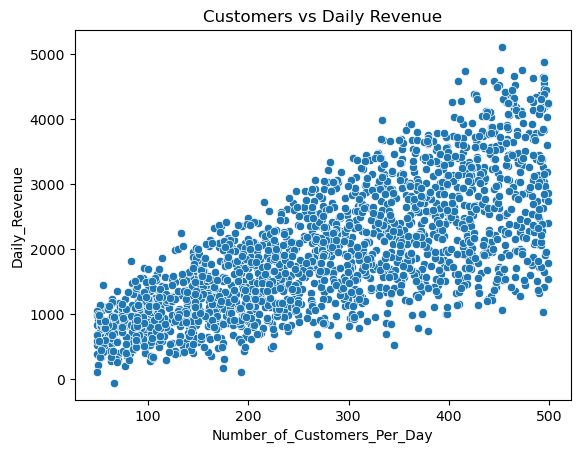

In [39]:
sns.scatterplot(x='Number_of_Customers_Per_Day', y='Daily_Revenue', data=df)
plt.title("Customers vs Daily Revenue")
plt.show()

## Observation:
### The scatter plot shows a positive relationship between Number of Customers per Day and Daily Revenue, indicating that as customer count increases, revenue generally rises, though some variation suggests other factors may also influence revenue.

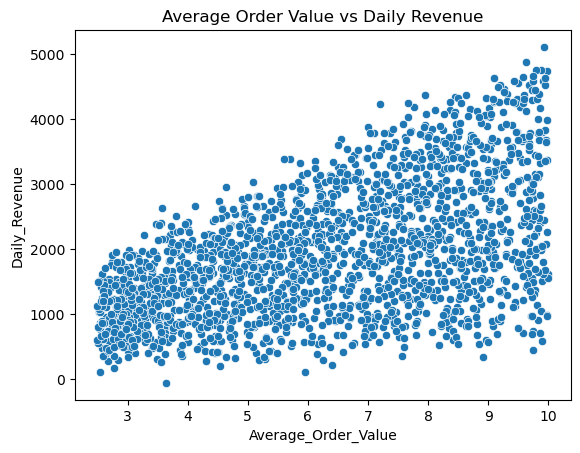

In [40]:
sns.scatterplot(x='Average_Order_Value', y='Daily_Revenue', data=df)
plt.title("Average Order Value vs Daily Revenue")
plt.show()


## Observation:
### The scatter plot indicates a strong positive relationship between Average Order Value and Daily Revenue, suggesting that higher spending per customer leads to increased overall revenue, with relatively consistent growth and fewer fluctuations.

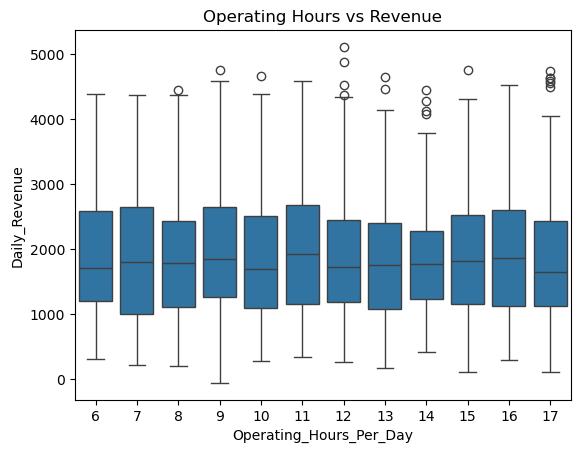

In [41]:
sns.boxplot(x='Operating_Hours_Per_Day', y='Daily_Revenue', data=df)
plt.title("Operating Hours vs Revenue")
plt.show()

## Observation:
### The box plot shows that Daily Revenue generally increases with longer Operating Hours per Day, indicating that shops open for more hours tend to generate higher revenue, though variability suggests other factors also influence earnings.

## Start applying machine learning algorithm 

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [43]:
x=df.drop('Daily_Revenue',axis=1)
# multiple features 
y=df['Daily_Revenue']
# target output 

In [44]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
# train and test model for better observation 

In [45]:
rf=RandomForestRegressor(random_state=42)
# creates a Random Forest model with a fixed random seed for reproducible results.

In [46]:
rf.fit(x_train,y_train)
# trains the Random Forest model using the training data to learn the relationship between features and target. 

RandomForestRegressor(random_state=42)

In [47]:
y_pred=rf.predict(x_test)
# This code separates the dataset into features (X) and the target variable (y). 
# Here, X contains all input columns except Outcome, and y contains the Outcome column which is used for prediction.

In [48]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print('Mean Absolute Error:',mae)
print('Mean Squared Error:',mse)
print('Root mean squared Error:',rmse)




Mean Absolute Error: 175.3933364999999
Mean Squared Error: 47501.55401971976
Root mean squared Error: 217.94851231361906


In [49]:
param_grid={
    'n_estimators':[10,50,100,150],
    'max_depth':[None,5,10,15],
     'min_samples_split':[2,5,8,10]}       


In [50]:
rf1=RandomForestRegressor(random_state=42)

In [51]:
grid_search=GridSearchCV(estimator=rf1,param_grid=param_grid,cv=5,n_jobs=-1,verbose=2)

In [52]:
grid_search.fit(x_train,y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'min_samples_split': [2, 5, 8, 10],
                         'n_estimators': [10, 50, 100, 150]},
             verbose=2)

In [53]:
print('Best Parameters:' ,grid_search.best_params_)

Best Parameters: {'max_depth': 15, 'min_samples_split': 8, 'n_estimators': 150}


In [54]:
best_model=grid_search.best_estimator_
pred=best_model.predict(x_test)

In [55]:
mae=mean_absolute_error(y_test,pred)
mse=mean_squared_error(y_test,pred)
rmse=np.sqrt(mse)
print('Mean Absolute Error:',mae)
print('Mean Squared Error:',mse)
print('Root mean squared Error:',rmse)

Mean Absolute Error: 178.03980387690157
Mean Squared Error: 48952.56556798771
Root mean squared Error: 221.25226680869895


In [56]:
r2=r2_score(y_test,pred)
print('R2 Score:',r2)

R2 Score: 0.9476089365329832


In [57]:
rf.score(x_train,y_train)

0.9923019877341922

In [58]:
rf.score(x_test,y_test)

0.9491618691981997